In [ ]:
# Cell 1: Kiểm tra GPU
import torch
print(torch.cuda.is_available())          # Phải ra True
print(torch.cuda.get_device_name(0))      # Ví dụ: Tesla T4

True
Tesla T4


In [ ]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np

# Cell 3: Data augmentation & loading
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

# Download CIFAR-10
full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
test_set   = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

# Chia train/val: 45k / 5k
train_size = 45000
val_size   = 5000
train_set, val_set = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42))

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

100%|██████████| 170M/170M [00:08<00:00, 20.0MB/s]


Train: 45000 | Val: 5000 | Test: 10000


In [ ]:
# Cell 4: ResNet-18 cho CIFAR-10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_model():
    model = resnet18(pretrained=False)
    # CIFAR-10 ảnh 32x32 → thay conv1 và bỏ maxpool
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 10)   # 10 classes
    return model.to(device)

model = build_model()
print(f"Tổng params: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Tổng params: 11,173,962


In [ ]:
# Cell 5: Training
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

# Cell 6: Vòng lặp chính
EPOCHS = 50
best_val_acc = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    # Lưu checkpoint tốt nhất
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ Epoch {epoch:3d} | Saved best | Val acc: {va_acc:.4f}")
    elif epoch % 10 == 0:
        print(f"  Epoch {epoch:3d} | tr_loss={tr_loss:.4f} | val_acc={va_acc:.4f}")

✓ Epoch   1 | Saved best | Val acc: 0.5772
✓ Epoch   2 | Saved best | Val acc: 0.7004
✓ Epoch   3 | Saved best | Val acc: 0.7778
✓ Epoch   4 | Saved best | Val acc: 0.7888
✓ Epoch   6 | Saved best | Val acc: 0.8112
✓ Epoch   8 | Saved best | Val acc: 0.8168
✓ Epoch   9 | Saved best | Val acc: 0.8326
✓ Epoch  10 | Saved best | Val acc: 0.8534
✓ Epoch  11 | Saved best | Val acc: 0.8580
✓ Epoch  12 | Saved best | Val acc: 0.8602
✓ Epoch  13 | Saved best | Val acc: 0.8688
✓ Epoch  16 | Saved best | Val acc: 0.8798
✓ Epoch  18 | Saved best | Val acc: 0.8806
✓ Epoch  20 | Saved best | Val acc: 0.8924
✓ Epoch  22 | Saved best | Val acc: 0.8984
✓ Epoch  23 | Saved best | Val acc: 0.9006
✓ Epoch  24 | Saved best | Val acc: 0.9012
✓ Epoch  25 | Saved best | Val acc: 0.9022
✓ Epoch  28 | Saved best | Val acc: 0.9032
  Epoch  30 | tr_loss=0.0885 | val_acc=0.8948
✓ Epoch  31 | Saved best | Val acc: 0.9236
✓ Epoch  32 | Saved best | Val acc: 0.9246
✓ Epoch  33 | Saved best | Val acc: 0.9258
✓ Epoch 

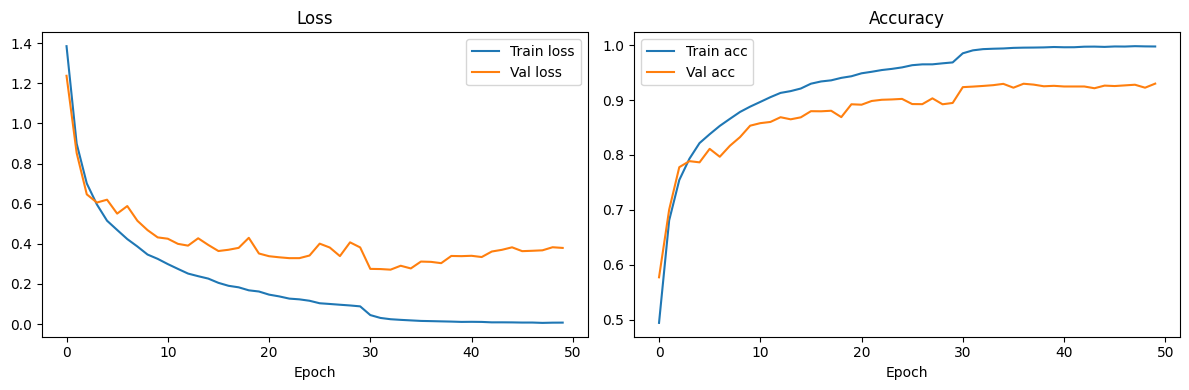

Test Accuracy: 0.9292 (92.92%)


In [ ]:
# Cell 7: Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train loss')
ax1.plot(history['val_loss'],   label='Val loss')
ax1.set_title('Loss'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history['train_acc'], label='Train acc')
ax2.plot(history['val_acc'],   label='Val acc')
ax2.set_title('Accuracy'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Cell 8: Đánh giá trên test set
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc = eval_epoch(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

In [ ]:
# Cell 9: Inference function — bàn giao cho team OOD
def get_logits(model, loader, device):
    """
    Trả về (logits, labels) dạng numpy array.
    Team OOD dùng hàm này để tính Energy Score.
    """
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)           # shape: (batch, 10)
            all_logits.append(logits.cpu())
            all_labels.append(labels)
    return torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy()

# Ví dụ dùng:
logits, labels = get_logits(model, test_loader, device)
print("Logits shape:", logits.shape)      # (10000, 10)
print("Labels shape:", labels.shape)     # (10000,)

# Lưu logits ra file để team khác dùng
np.save('cifar10_test_logits.npy', logits)
np.save('cifar10_test_labels.npy', labels)

Logits shape: (10000, 10)
Labels shape: (10000,)


In [ ]:
# Cell 10: Download các file bàn giao
from google.colab import files

files.download('best_model.pth')           # Checkpoint
files.download('cifar10_test_logits.npy')  # Logits
files.download('cifar10_test_labels.npy')  # Labels
files.download('training_curves.png')      # Biểu đồ

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>